# 모의 투자 시뮬레이션 — LightGBM 3일 후 주가 방향 예측

| 항목 | 내용 |
|------|------|
| 예측 모델 | LightGBM (단일 분할 학습) |
| 진입 조건 | `lgb_prob > THRESHOLD` |
| 보유 기간 | 3 거래일 |
| 포지션 | 동일 가중 (equal-weight) |
| 시뮬레이션 기간 | 2026-02-01 ~ 2026-04-01 |
| 벤치마크 | 전체 종목 동일 가중 KOSPI |

**실행 순서**: STEP 1 → 2 → … → 10 순서대로 실행하세요.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# [STEP 1] Google Drive 마운트 & 경로 설정
import os

# ★ 본인 Drive 경로로 수정하세요
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/ml_project"

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = DRIVE_PROJECT_PATH
    print(f"[Drive 마운트 완료] BASE_DIR={BASE_DIR}")
except Exception:
    BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
    print(f"[로컬 환경] BASE_DIR={BASE_DIR}")

DATA_DIR   = BASE_DIR
RESULT_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULT_DIR, exist_ok=True)

# OHLCV 파일 경로 (둘 중 하나만 있으면 됨)
OHLCV_ALL_PATH = os.path.join(BASE_DIR, "ohlcv_all.csv")  # 통합 csv
OHLCV_DIR      = os.path.join(BASE_DIR, "ohlcv")           # 종목별 csv 폴더

print(f"DATA_DIR   : {DATA_DIR}")
print(f"RESULT_DIR : {RESULT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Drive 마운트 완료] BASE_DIR=/content/drive/MyDrive/ml_project
DATA_DIR   : /content/drive/MyDrive/ml_project
RESULT_DIR : /content/drive/MyDrive/ml_project/results


In [4]:
# [STEP 2] 라이브러리 임포트 & 한글 폰트 설정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager
import lightgbm as lgb
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore")

# Colab 한글 폰트
try:
    import subprocess
    subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
    font_manager.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    plt.rcParams["font.family"] = "NanumGothic"
    print("[폰트] NanumGothic 설정 완료")
except Exception:
    print("[폰트] 기본 폰트 사용 (한글 깨질 수 있음)")

plt.rcParams["axes.unicode_minus"] = False
print("라이브러리 로드 완료")

[폰트] NanumGothic 설정 완료
라이브러리 로드 완료


In [6]:
# [STEP 3] dataset.npz 로드
NPZ_NAMES = ["dataset9.npz", "dataset.npz", "dataset1.npz"]
npz_path  = None
for name in NPZ_NAMES:
    cand = os.path.join(DATA_DIR, name)
    if os.path.exists(cand):
        npz_path = cand
        break

assert npz_path, f"dataset.npz 를 찾을 수 없습니다. DATA_DIR={DATA_DIR}"
data = np.load(npz_path, allow_pickle=True)
print(f"[로드] {npz_path}")
print(f"  포함된 키: {list(data.files)}")

X_train     = data["X_train"]
X_test      = data["X_test"]
y_train     = data["y_train"]
y_test      = data["y_test"]
train_dates = pd.to_datetime(data["train_dates"]) if "train_dates" in data.files else None
test_dates  = pd.to_datetime(data["test_dates"])  if "test_dates"  in data.files else None
test_codes  = data["test_codes"]                  if "test_codes"  in data.files else None

assert train_dates is not None, "train_dates 없음 → 04_build_dataset.ipynb 재실행 필요"
assert test_dates  is not None, "test_dates 없음  → 04_build_dataset.ipynb 재실행 필요"
assert test_codes  is not None, "test_codes 없음  → 04_build_dataset.ipynb 재실행 필요"

print(f"\nX_train  : {X_train.shape}")
print(f"X_test   : {X_test.shape}")
print(f"test 기간: {test_dates.min().date()} ~ {test_dates.max().date()}")
print(f"test 종목: {len(set(test_codes)):,}개")
print(f"y_test Up 비율: {y_test.mean():.3f}")

[로드] /content/drive/MyDrive/ml_project/dataset9.npz
  포함된 키: ['X_train', 'X_test', 'y_train', 'y_test', 'feature_cols', 'train_codes', 'train_dates', 'test_codes', 'test_dates']

X_train  : (92169, 20, 28)
X_test   : (18124, 20, 28)
test 기간: 2026-02-06 ~ 2026-03-27
test 종목: 806개
y_test Up 비율: 0.498


In [7]:
# [STEP 4] LightGBM 학습
# 05_train_lstm_improved2.ipynb 와 동일한 하이퍼파라미터 사용

LGB_PARAMS = dict(
    n_estimators      = 800,
    learning_rate     = 0.02,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.05,
    reg_lambda        = 0.5,
    scale_pos_weight  = 1.2,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

X_tr_flat = X_train.reshape(len(X_train), -1)
X_te_flat = X_test.reshape(len(X_test),   -1)

n_val     = max(1, int(len(X_tr_flat) * 0.15))
model_lgb = lgb.LGBMClassifier(**LGB_PARAMS)

print(f"학습 샘플: {len(X_tr_flat)-n_val:,}  검증 샘플: {n_val:,}")

model_lgb.fit(
    X_tr_flat[:-n_val], y_train[:-n_val],
    eval_set=[(X_tr_flat[-n_val:], y_train[-n_val:])],
    callbacks=[lgb.early_stopping(100, verbose=False),
               lgb.log_evaluation(200)],
)

lgb_probs = model_lgb.predict_proba(X_te_flat)[:, 1]
print(f"\n[완료] 테스트 확률값 생성: {len(lgb_probs):,}개")
print(f"  prob 평균={lgb_probs.mean():.4f}  std={lgb_probs.std():.4f}")
print(f"  >0.50: {(lgb_probs>0.50).sum():,}개  >0.55: {(lgb_probs>0.55).sum():,}개  >0.60: {(lgb_probs>0.60).sum():,}개")

학습 샘플: 78,344  검증 샘플: 13,825
[200]	valid_0's binary_logloss: 0.638661
[400]	valid_0's binary_logloss: 0.637036
[600]	valid_0's binary_logloss: 0.636013
[800]	valid_0's binary_logloss: 0.635589

[완료] 테스트 확률값 생성: 18,124개
  prob 평균=0.4229  std=0.2390
  >0.50: 6,820개  >0.55: 5,827개  >0.60: 4,754개


In [8]:
# [STEP 5] 예측 결과 DataFrame 구성 & 시뮬레이션 구간 필터링

df_pred = pd.DataFrame({
    "code"  : test_codes,
    "date"  : pd.to_datetime(test_dates),
    "prob"  : lgb_probs,
    "actual": y_test.astype(int),
})
df_pred["date"] = df_pred["date"].dt.normalize()
df_pred = df_pred.sort_values("date").reset_index(drop=True)

# ★ 시뮬레이션 기간 (조정 가능)
SIM_START = pd.Timestamp("2026-02-01")
SIM_END   = pd.Timestamp("2026-04-01")

df_sim = df_pred[
    (df_pred["date"] >= SIM_START) &
    (df_pred["date"] <  SIM_END)
].copy()

print(f"[시뮬레이션 대상]")
print(f"  기간   : {df_sim['date'].min().date()} ~ {df_sim['date'].max().date()}")
print(f"  날짜 수 : {df_sim['date'].nunique()}일")
print(f"  샘플 수 : {len(df_sim):,}개  (종목 × 날짜)")
print(f"  Up 비율 : {df_sim['actual'].mean():.3f}")

[시뮬레이션 대상]
  기간   : 2026-02-06 ~ 2026-03-27
  날짜 수 : 32일
  샘플 수 : 18,124개  (종목 × 날짜)
  Up 비율 : 0.498


In [9]:
# [STEP 6] OHLCV 로드 (3일 후 실제 수익률 계산용)
# ohlcv_all.csv → ohlcv/ 폴더 → features.csv 순으로 자동 탐색

def load_ohlcv():
    if os.path.exists(OHLCV_ALL_PATH):
        print(f"[OHLCV] 통합 파일 로드: {OHLCV_ALL_PATH}")
        df = pd.read_csv(OHLCV_ALL_PATH, parse_dates=["date"])
        df["code"] = df["code"].astype(str).str.zfill(6)
        return df[["code", "date", "close"]]

    if os.path.isdir(OHLCV_DIR):
        print(f"[OHLCV] 종목별 폴더 로드: {OHLCV_DIR}")
        parts = []
        for fname in os.listdir(OHLCV_DIR):
            if not fname.endswith(".csv"):
                continue
            tmp = pd.read_csv(os.path.join(OHLCV_DIR, fname), parse_dates=["date"])
            tmp["code"] = tmp["code"].astype(str).str.zfill(6)
            parts.append(tmp[["code", "date", "close"]])
        if parts:
            return pd.concat(parts, ignore_index=True).sort_values(["code", "date"]).reset_index(drop=True)

    feat_path = os.path.join(DATA_DIR, "features.csv")
    if os.path.exists(feat_path):
        print(f"[OHLCV] features.csv 에서 close 추출")
        df = pd.read_csv(feat_path, parse_dates=["date"], usecols=["code", "date", "close"])
        df["code"] = df["code"].astype(str).str.zfill(6)
        return df

    print("[경고] OHLCV 파일 없음 → 라벨 기반 수익률 사용 (Up=+1%, Down=-1%)")
    return None


df_ohlcv = load_ohlcv()

if df_ohlcv is not None:
    all_trading_days = sorted(df_ohlcv["date"].unique())
    print(f"[OHLCV] 거래일 수: {len(all_trading_days):,}  "
          f"({pd.Timestamp(all_trading_days[0]).date()} ~ "
          f"{pd.Timestamp(all_trading_days[-1]).date()})")

[OHLCV] features.csv 에서 close 추출
[OHLCV] 거래일 수: 2,716  (2015-03-09 ~ 2026-03-31)


In [10]:
# [STEP 7] 시뮬레이션 함수 정의

def get_next_trading_day(base_date, n, trading_days):
    """base_date 이후 n번째 거래일 반환. 없으면 None."""
    future = [d for d in trading_days if d > base_date]
    return future[n - 1] if len(future) >= n else None


def run_simulation(df_pred_sim, df_ohlcv, threshold, hold_days, max_picks=None, label="전략"):
    """
    3일 단위 매수-매도 반복 시뮬레이션.

    Returns
    -------
    records  : list[dict]  개별 거래 기록
    df_daily : DataFrame   슬롯별 전략/벤치마크 수익률 + 누적 수익률
    """
    trading_days = sorted(df_ohlcv["date"].unique()) if df_ohlcv is not None else None
    pred_dates   = sorted(df_pred_sim["date"].unique())
    entry_dates  = pred_dates[::hold_days]   # 3거래일 간격 진입 시점

    records    = []
    daily_rets = {}

    print(f"[{label}] 진입 슬롯: {len(entry_dates)}회 | threshold={threshold} | 보유={hold_days}일")

    for entry_date in entry_dates:
        day_df = df_pred_sim[df_pred_sim["date"] == entry_date]
        picks  = day_df[day_df["prob"] >= threshold].sort_values("prob", ascending=False)
        if max_picks:
            picks = picks.head(max_picks)
        if len(picks) == 0:
            continue

        exit_date = (get_next_trading_day(entry_date, hold_days, trading_days)
                     if trading_days else None)

        slot_rets = []
        for _, row in picks.iterrows():
            code = row["code"]
            if df_ohlcv is not None and exit_date is not None:
                er = df_ohlcv[(df_ohlcv["code"] == code) & (df_ohlcv["date"] == entry_date)]
                xr = df_ohlcv[(df_ohlcv["code"] == code) & (df_ohlcv["date"] == exit_date)]
                if er.empty or xr.empty:
                    continue
                ret = (xr["close"].iloc[0] - er["close"].iloc[0]) / er["close"].iloc[0]
            else:
                ret = 0.01 if row["actual"] == 1 else -0.01

            records.append({
                "entry_date": entry_date,
                "exit_date" : exit_date,
                "code"      : code,
                "prob"      : round(row["prob"], 4),
                "actual"    : int(row["actual"]),
                "return"    : round(ret, 6),
                "correct"   : int(row["actual"] == 1),
            })
            slot_rets.append(ret)

        if slot_rets:
            daily_rets[entry_date] = float(np.mean(slot_rets))

    # 벤치마크: 전체 종목 동일 가중 수익률
    bench_daily = {}
    all_codes = df_pred_sim["code"].unique()
    for entry_date in entry_dates:
        if df_ohlcv is not None:
            exit_date = get_next_trading_day(entry_date, hold_days, trading_days) if trading_days else None
            if exit_date is None:
                continue
            brets = []
            for code in all_codes:
                er = df_ohlcv[(df_ohlcv["code"] == code) & (df_ohlcv["date"] == entry_date)]
                xr = df_ohlcv[(df_ohlcv["code"] == code) & (df_ohlcv["date"] == exit_date)]
                if er.empty or xr.empty:
                    continue
                brets.append((xr["close"].iloc[0] - er["close"].iloc[0]) / er["close"].iloc[0])
            if brets:
                bench_daily[entry_date] = float(np.mean(brets))
        else:
            day_df = df_pred_sim[df_pred_sim["date"] == entry_date]
            bench_daily[entry_date] = float(np.mean([0.01 if r == 1 else -0.01 for r in day_df["actual"]]))

    # 누적 수익률 계산
    all_dates = sorted(set(list(daily_rets.keys()) + list(bench_daily.keys())))
    df_daily  = pd.DataFrame(index=all_dates)
    df_daily.index.name = "date"
    df_daily["strategy"]  = [daily_rets.get(d, np.nan)  for d in all_dates]
    df_daily["benchmark"] = [bench_daily.get(d, np.nan) for d in all_dates]
    df_daily["n_picks"]   = [len(df_pred_sim[(df_pred_sim["date"] == d) & (df_pred_sim["prob"] >= threshold)]) for d in all_dates]
    df_daily["cum_strategy"]  = (1 + df_daily["strategy"].fillna(0)).cumprod() - 1
    df_daily["cum_benchmark"] = (1 + df_daily["benchmark"].fillna(0)).cumprod() - 1
    df_daily["cum_excess"]    = df_daily["cum_strategy"] - df_daily["cum_benchmark"]

    return records, df_daily


print("[함수 정의 완료] run_simulation, get_next_trading_day")

[함수 정의 완료] run_simulation, get_next_trading_day


In [11]:
# [STEP 8] 시뮬레이션 실행
# ★ 아래 파라미터를 조정하세요

THRESHOLD = 0.55   # 매수 진입 확률 임계값 (0.50 ~ 0.70 권장)
HOLD_DAYS = 3      # 보유 거래일 수 (모델 예측 지평과 동일)
MAX_PICKS = 30     # 1회 최대 매수 종목 수 (None = 제한 없음)

records, df_daily = run_simulation(
    df_pred_sim = df_sim,
    df_ohlcv    = df_ohlcv,
    threshold   = THRESHOLD,
    hold_days   = HOLD_DAYS,
    max_picks   = MAX_PICKS,
    label       = f"LightGBM(thr={THRESHOLD})",
)
df_trades = pd.DataFrame(records)

# ── 성과 요약 출력 ──────────────────────────────
n_slots  = len(df_daily)
n_trades = len(df_trades)

if n_trades == 0:
    print("[경고] 거래 없음 → THRESHOLD를 낮춰 보세요")
else:
    final_strat  = df_daily["cum_strategy"].iloc[-1]  * 100
    final_bench  = df_daily["cum_benchmark"].iloc[-1] * 100
    final_excess = df_daily["cum_excess"].iloc[-1]    * 100
    win_days     = (df_daily["strategy"] > df_daily["benchmark"]).sum()
    hit_days     = (df_daily["strategy"] > 0).sum()
    avg_picks    = df_daily["n_picks"].mean()
    hit_rate     = df_trades["correct"].mean()
    avg_ret      = df_trades["return"].mean()

    print("\n" + "="*55)
    print(f"  모의 투자 결과  (threshold={THRESHOLD})")
    print("="*55)
    print(f"  테스트 기간    : {df_daily.index[0].date()} ~ {df_daily.index[-1].date()}")
    print(f"  거래 슬롯 수   : {n_slots}회  (3거래일 단위)")
    print(f"  총 거래 건수   : {n_trades:,}건")
    print(f"  평균 매수 종목 : {avg_picks:.1f}개/회")
    print(f"  매수 정확도    : {hit_rate*100:.1f}%  (실제 Up 비율)")
    print(f"  거래당 평균 수익: {avg_ret*100:.3f}%")
    print("-"*55)
    print(f"  누적 전략 수익률: {final_strat:+.2f}%")
    print(f"  누적 벤치마크  : {final_bench:+.2f}%")
    print(f"  누적 초과 수익률: {final_excess:+.2f}%")
    print(f"  벤치마크 상회일 : {win_days}/{n_slots}  ({win_days/n_slots*100:.0f}%)")
    print(f"  절대 수익 달성일: {hit_days}/{n_slots}  ({hit_days/n_slots*100:.0f}%)")
    print("="*55)

[LightGBM(thr=0.55)] 진입 슬롯: 11회 | threshold=0.55 | 보유=3일

  모의 투자 결과  (threshold=0.55)
  테스트 기간    : 2026-02-06 ~ 2026-03-26
  거래 슬롯 수   : 11회  (3거래일 단위)
  총 거래 건수   : 77건
  평균 매수 종목 : 191.5개/회
  매수 정확도    : 46.8%  (실제 Up 비율)
  거래당 평균 수익: -0.683%
-------------------------------------------------------
  누적 전략 수익률: +0.51%
  누적 벤치마크  : +7.70%
  누적 초과 수익률: -7.19%
  벤치마크 상회일 : 5/11  (45%)
  절대 수익 달성일: 6/11  (55%)


In [12]:
# [STEP 9] 결과 CSV 저장

trades_path = os.path.join(RESULT_DIR, "simulation_trades.csv")
daily_path  = os.path.join(RESULT_DIR, "simulation_daily.csv")

df_trades.to_csv(trades_path, index=False, encoding="utf-8-sig")
df_daily.to_csv(daily_path,   encoding="utf-8-sig")

print(f"거래 기록 저장  : {trades_path}  ({len(df_trades):,}건)")
print(f"일별 수익률 저장: {daily_path}  ({len(df_daily)}행)")
print()
print(df_daily[["strategy", "benchmark", "n_picks", "cum_strategy", "cum_benchmark", "cum_excess"]]
      .head(10)
      .applymap(lambda x: f"{x*100:.3f}%" if isinstance(x, float) and abs(x) < 10 else x)
      .to_string())

거래 기록 저장  : /content/drive/MyDrive/ml_project/results/simulation_trades.csv  (77건)
일별 수익률 저장: /content/drive/MyDrive/ml_project/results/simulation_daily.csv  (11행)

            strategy benchmark  n_picks cum_strategy cum_benchmark cum_excess
date                                                                         
2026-02-06    5.282%    5.931%      249       5.282%        5.931%    -0.649%
2026-02-11    0.551%    4.999%      177       5.862%       11.226%    -5.364%
2026-02-19   14.528%    5.561%      167      21.242%       17.411%     3.830%
2026-02-24    0.064%   -0.032%      138      21.319%       17.374%     3.945%
2026-02-27  -10.023%   -7.954%      204       9.160%        8.039%     1.121%
2026-03-05   -2.896%   -0.051%      169       5.998%        7.984%    -1.986%
2026-03-10    4.521%    3.020%      238      10.790%       11.245%    -0.455%
2026-03-13   -6.240%    2.224%      146       3.877%       13.719%    -9.842%
2026-03-18   -4.961%   -3.638%      221      -1.276%   

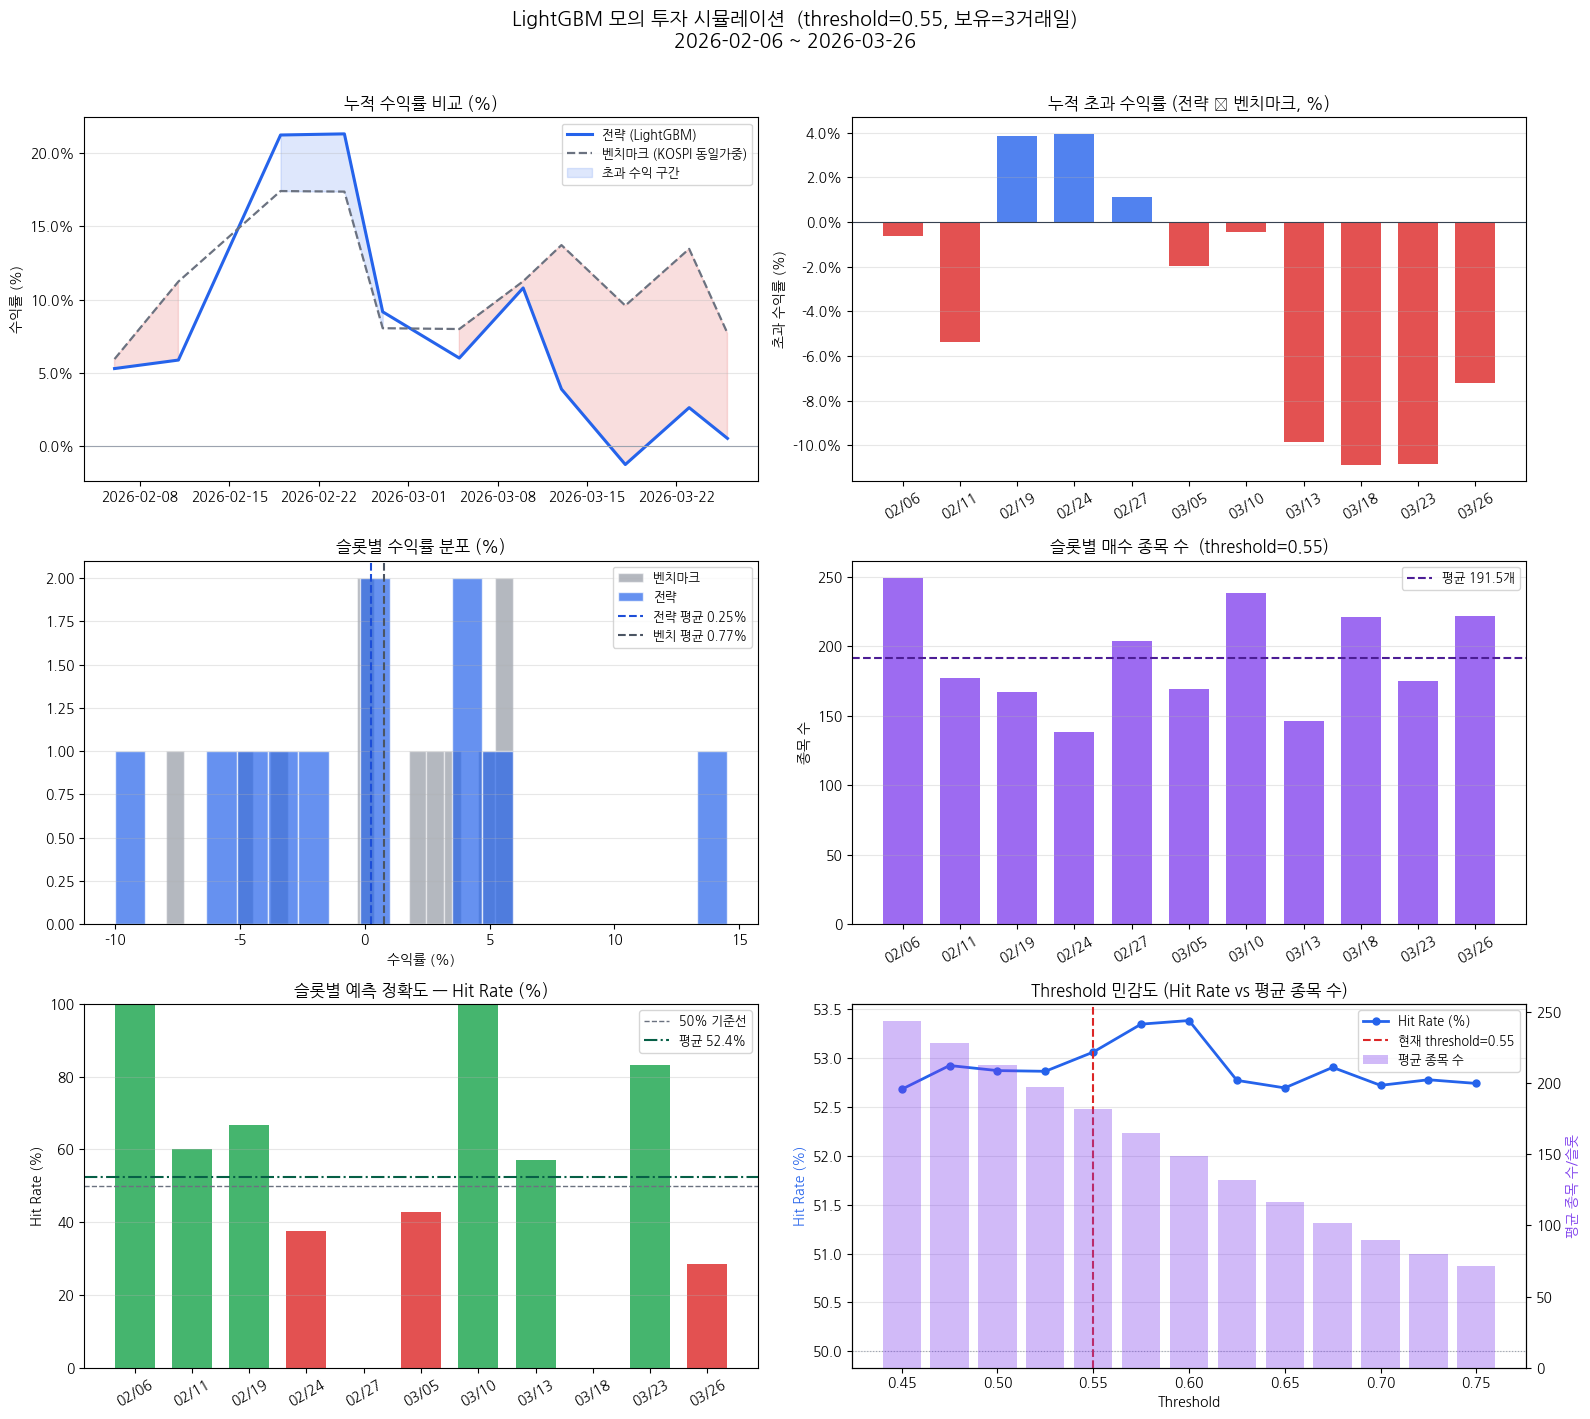

[저장] /content/drive/MyDrive/ml_project/results/mock_investment_result.png


In [13]:
# [STEP 10] 시각화 — 6패널 대시보드

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle(
    f"LightGBM 모의 투자 시뮬레이션  (threshold={THRESHOLD}, 보유={HOLD_DAYS}거래일)\n"
    f"{df_daily.index[0].date()} ~ {df_daily.index[-1].date()}",
    fontsize=14, fontweight="bold", y=1.01
)

dates = df_daily.index

# ── (1) 누적 수익률 비교 ──────────────────────────
ax = axes[0, 0]
ax.plot(dates, df_daily["cum_strategy"]  * 100, color="#2563EB", lw=2.2, label="전략 (LightGBM)")
ax.plot(dates, df_daily["cum_benchmark"] * 100, color="#6B7280", lw=1.6, ls="--", label="벤치마크 (KOSPI 동일가중)")
ax.fill_between(dates,
    df_daily["cum_strategy"] * 100, df_daily["cum_benchmark"] * 100,
    where=(df_daily["cum_strategy"] >= df_daily["cum_benchmark"]),
    alpha=0.15, color="#2563EB", label="초과 수익 구간")
ax.fill_between(dates,
    df_daily["cum_strategy"] * 100, df_daily["cum_benchmark"] * 100,
    where=(df_daily["cum_strategy"] < df_daily["cum_benchmark"]),
    alpha=0.15, color="#DC2626")
ax.axhline(0, color="#9CA3AF", lw=0.8)
ax.set_title("누적 수익률 비교 (%)", fontsize=12)
ax.set_ylabel("수익률 (%)")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.grid(axis="y", alpha=0.3)

# ── (2) 누적 초과 수익률 막대 ──────────────────────
ax = axes[0, 1]
excess = df_daily["cum_excess"] * 100
bar_colors = ["#2563EB" if v >= 0 else "#DC2626" for v in excess]
ax.bar(range(len(dates)), excess, color=bar_colors, alpha=0.8, width=0.7)
ax.axhline(0, color="#374151", lw=0.8)
ax.set_title("누적 초과 수익률 (전략 − 벤치마크, %)", fontsize=12)
ax.set_ylabel("초과 수익률 (%)")
ax.set_xticks(range(0, len(dates), max(1, len(dates)//6)))
ax.set_xticklabels([d.strftime("%m/%d") for d in dates[::max(1, len(dates)//6)]], rotation=30)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.grid(axis="y", alpha=0.3)

# ── (3) 슬롯별 수익률 분포 ─────────────────────────
ax = axes[1, 0]
slot_s = df_daily["strategy"].dropna()  * 100
slot_b = df_daily["benchmark"].dropna() * 100
ax.hist(slot_b, bins=20, alpha=0.5, color="#6B7280", label="벤치마크", edgecolor="white")
ax.hist(slot_s, bins=20, alpha=0.7, color="#2563EB", label="전략",     edgecolor="white")
ax.axvline(slot_s.mean(), color="#1D4ED8", lw=1.5, ls="--", label=f"전략 평균 {slot_s.mean():.2f}%")
ax.axvline(slot_b.mean(), color="#4B5563", lw=1.5, ls="--", label=f"벤치 평균 {slot_b.mean():.2f}%")
ax.set_title("슬롯별 수익률 분포 (%)", fontsize=12)
ax.set_xlabel("수익률 (%)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── (4) 매수 종목 수 추이 ──────────────────────────
ax = axes[1, 1]
ax.bar(range(len(dates)), df_daily["n_picks"], color="#7C3AED", alpha=0.75, width=0.7)
ax.axhline(df_daily["n_picks"].mean(), color="#4C1D95", lw=1.5, ls="--",
           label=f"평균 {df_daily['n_picks'].mean():.1f}개")
ax.set_title(f"슬롯별 매수 종목 수  (threshold={THRESHOLD})", fontsize=12)
ax.set_ylabel("종목 수")
ax.set_xticks(range(0, len(dates), max(1, len(dates)//6)))
ax.set_xticklabels([d.strftime("%m/%d") for d in dates[::max(1, len(dates)//6)]], rotation=30)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── (5) 슬롯별 Hit Rate ────────────────────────────
ax = axes[2, 0]
if len(df_trades) > 0:
    slot_hits = (df_trades.groupby("entry_date")
                 .agg(hit_rate=("correct", "mean"), n=("correct", "count"))
                 .reset_index())
    slot_hits["entry_date"] = pd.to_datetime(slot_hits["entry_date"])
    hcolors = ["#16A34A" if h >= 0.5 else "#DC2626" for h in slot_hits["hit_rate"]]
    ax.bar(range(len(slot_hits)), slot_hits["hit_rate"] * 100, color=hcolors, alpha=0.8, width=0.7)
    ax.axhline(50, color="#6B7280", lw=1, ls="--", label="50% 기준선")
    ax.axhline(slot_hits["hit_rate"].mean() * 100, color="#065F46", lw=1.5, ls="-.",
               label=f"평균 {slot_hits['hit_rate'].mean()*100:.1f}%")
    ax.set_title("슬롯별 예측 정확도 — Hit Rate (%)", fontsize=12)
    ax.set_ylabel("Hit Rate (%)")
    ax.set_xticks(range(0, len(slot_hits), max(1, len(slot_hits)//6)))
    ax.set_xticklabels(
        [d.strftime("%m/%d") for d in slot_hits["entry_date"].iloc[::max(1, len(slot_hits)//6)]],
        rotation=30)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

# ── (6) Threshold 민감도 분석 ──────────────────────
ax = axes[2, 1]
thresholds   = np.arange(0.45, 0.76, 0.025)
thr_results  = []
for t in thresholds:
    picks_t = df_sim[df_sim["prob"] >= t]
    if len(picks_t) == 0:
        thr_results.append((t, 0, 0))
        continue
    hit   = picks_t["actual"].mean() * 100
    avg_n = picks_t.groupby("date").size().mean()
    thr_results.append((t, hit, avg_n))
thr_df = pd.DataFrame(thr_results, columns=["threshold", "hit_rate", "avg_picks"])

ax2 = ax.twinx()
ax.plot(thr_df["threshold"], thr_df["hit_rate"],  color="#2563EB", lw=2, marker="o", ms=5, label="Hit Rate (%)")
ax2.bar(thr_df["threshold"], thr_df["avg_picks"], width=0.02, alpha=0.35, color="#7C3AED", label="평균 종목 수")
ax.axvline(THRESHOLD, color="#DC2626", lw=1.5, ls="--", label=f"현재 threshold={THRESHOLD}")
ax.axhline(50, color="#9CA3AF", lw=0.8, ls=":")
ax.set_title("Threshold 민감도 (Hit Rate vs 평균 종목 수)", fontsize=12)
ax.set_xlabel("Threshold")
ax.set_ylabel("Hit Rate (%)", color="#2563EB")
ax2.set_ylabel("평균 종목 수/슬롯", color="#7C3AED")
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_path = os.path.join(RESULT_DIR, "mock_investment_result.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[저장] {save_path}")

[thr=0.5] 진입 슬롯: 11회 | threshold=0.5 | 보유=3일
[thr=0.55] 진입 슬롯: 11회 | threshold=0.55 | 보유=3일
[thr=0.6] 진입 슬롯: 11회 | threshold=0.6 | 보유=3일
[thr=0.65] 진입 슬롯: 11회 | threshold=0.65 | 보유=3일


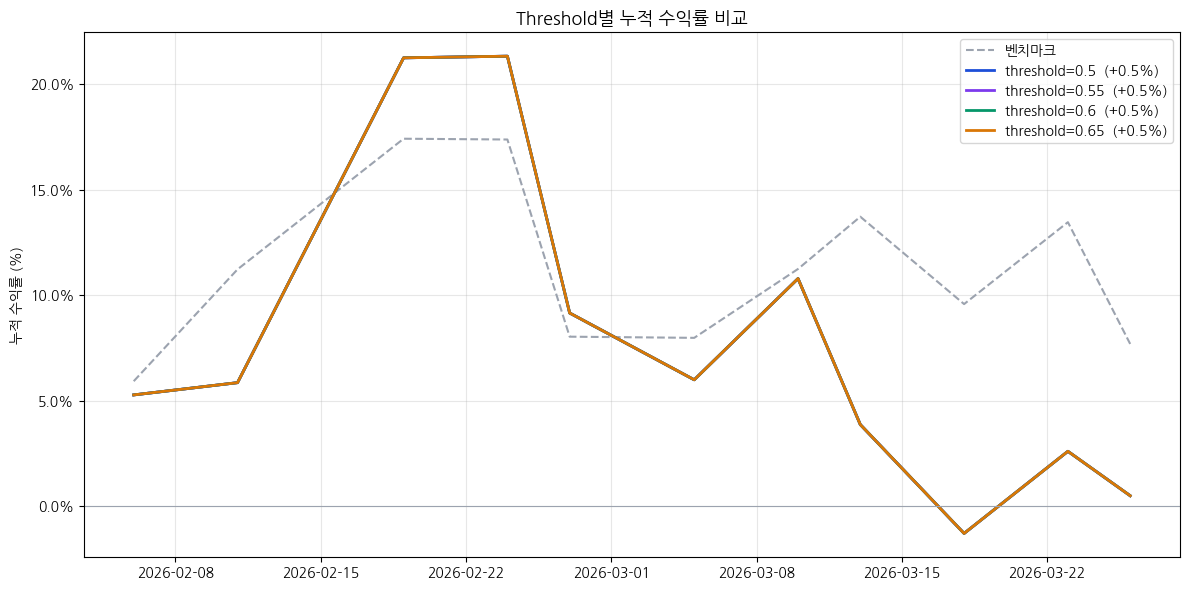

[저장] /content/drive/MyDrive/ml_project/results/threshold_comparison.png

✅ 모의 투자 시뮬레이션 완료
   결과 파일: /content/drive/MyDrive/ml_project/results


In [14]:
# [STEP 11] Threshold별 누적 수익률 비교

fig, ax = plt.subplots(figsize=(12, 6))
COMPARE_THRESHOLDS = [0.50, 0.55, 0.60, 0.65]
colors = ["#1D4ED8", "#7C3AED", "#059669", "#D97706"]

bench_plotted = False
for i, thr in enumerate(COMPARE_THRESHOLDS):
    _, df_d = run_simulation(
        df_pred_sim=df_sim, df_ohlcv=df_ohlcv,
        threshold=thr, hold_days=HOLD_DAYS, max_picks=MAX_PICKS,
        label=f"thr={thr}"
    )
    if not bench_plotted and len(df_d) > 0:
        ax.plot(df_d.index, df_d["cum_benchmark"] * 100,
                color="#9CA3AF", lw=1.5, ls="--", label="벤치마크")
        bench_plotted = True
    if len(df_d) > 0:
        final = df_d["cum_strategy"].iloc[-1] * 100
        ax.plot(df_d.index, df_d["cum_strategy"] * 100,
                color=colors[i], lw=2, label=f"threshold={thr}  ({final:+.1f}%)")

ax.axhline(0, color="#9CA3AF", lw=0.8)
ax.set_title("Threshold별 누적 수익률 비교", fontsize=13, fontweight="bold")
ax.set_ylabel("누적 수익률 (%)")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.grid(alpha=0.3)
plt.tight_layout()
save_path2 = os.path.join(RESULT_DIR, "threshold_comparison.png")
fig.savefig(save_path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"[저장] {save_path2}")

print("\n✅ 모의 투자 시뮬레이션 완료")
print(f"   결과 파일: {RESULT_DIR}")